In [1]:
!pip install Pillow matplotlib

In [2]:
# Import thư viện
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
from google.colab import drive
import os
# Kết nối Google Drive
drive.mount('/content/drive')
print("Hoàn tất cài đặt!")

Mounted at /content/drive
Hoàn tất cài đặt!


Các ảnh có sẵn:
1. bai3_flip_horizontal.png
2. bai3_flip_vertical.png


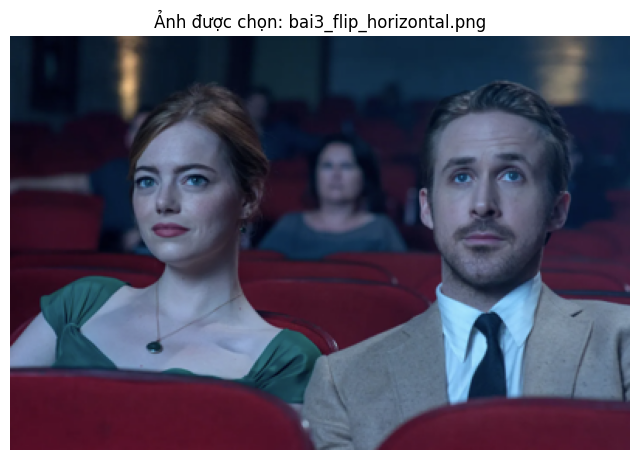

In [3]:
# Thiết lập đường dẫn (thay đổi theo thư mục của bạn)
THU_MUC_ANH = "/content/drive/MyDrive/Lab_Images/"
# Liệt kê và chọn ảnh
def setup_anh():
  global img_goc, danh_sach_anh
  # Lấy danh sách ảnh
  files = os.listdir(THU_MUC_ANH)
  danh_sach_anh = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
  print("Các ảnh có sẵn:")
  for i, file in enumerate(danh_sach_anh, 1):
    print(f"{i}. {file}")
  # Mở ảnh đầu tiên (thay số để chọn ảnh khác)
  chon_anh = 0  # Thay đổi index này để chọn ảnh khác
  duong_dan = os.path.join(THU_MUC_ANH, danh_sach_anh[chon_anh])
  img_goc = Image.open(duong_dan)
  # Hiển thị ảnh đã chọn
  plt.figure(figsize=(8, 6))
  plt.imshow(img_goc)
  plt.title(f"Ảnh được chọn: {danh_sach_anh[chon_anh]}")
  plt.axis('off')
  plt.show()
  return img_goc
  # Chạy setup
img_goc = setup_anh()

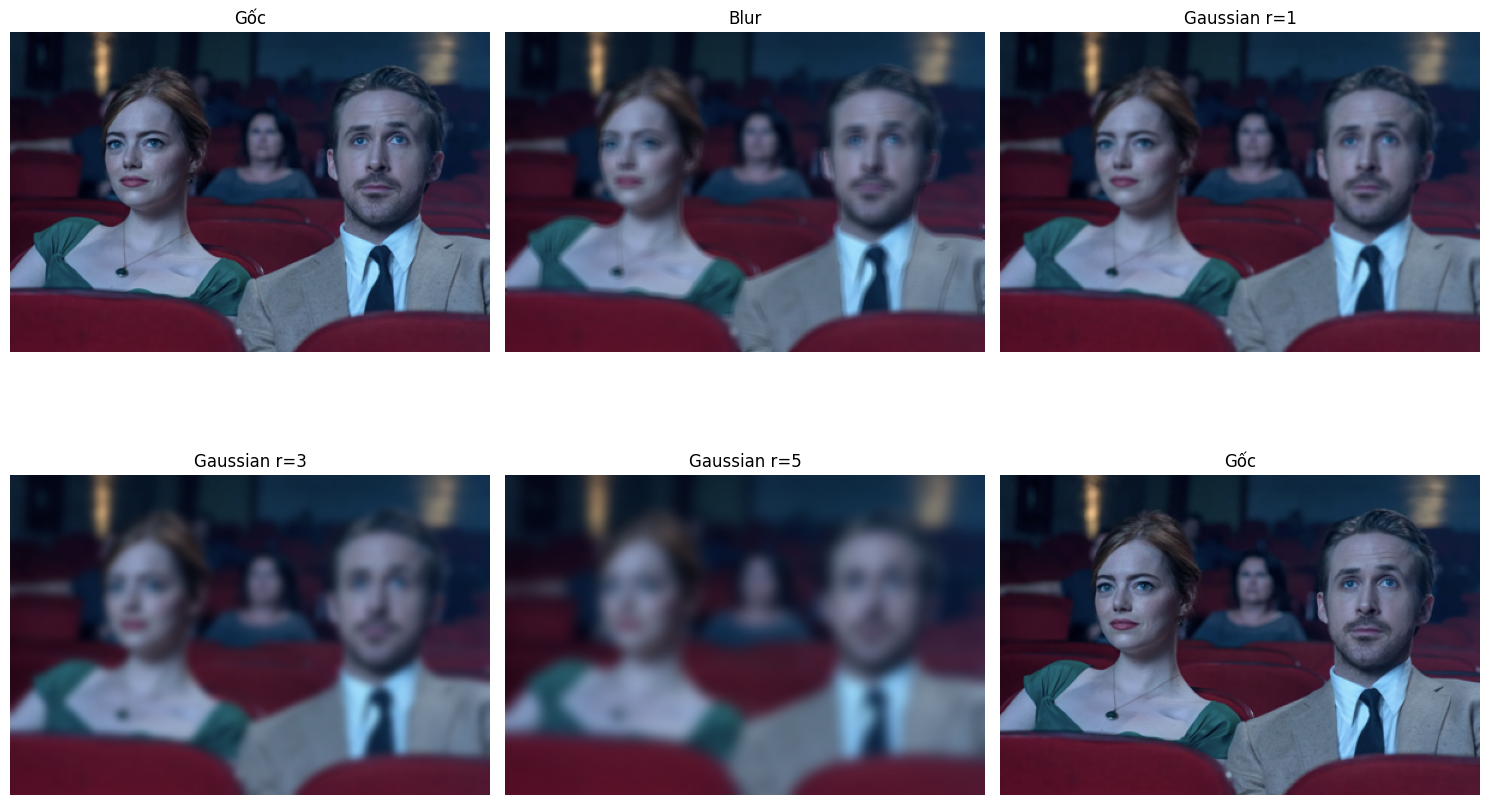

In [6]:
def thuc_hanh_blur():
  # Blur cơ bản
  blur_img = img_goc.filter(ImageFilter.BLUR)
  # Gaussian blur với các mức độ khác nhau
  gaussian_1 = img_goc.filter(ImageFilter.GaussianBlur(radius=1))
  gaussian_3 = img_goc.filter(ImageFilter.GaussianBlur(radius=3))
  gaussian_5 = img_goc.filter(ImageFilter.GaussianBlur(radius=5))
  # Hiển thị so sánh
  fig, axes = plt.subplots(2, 3, figsize=(15, 10))
  images = [img_goc, blur_img, gaussian_1, gaussian_3, gaussian_5, img_goc]
  titles = ['Gốc', 'Blur', 'Gaussian r=1', 'Gaussian r=3', 'Gaussian r=5', 'Gốc']
  for i, (image, title) in enumerate(zip(images, titles)):
    row, col = i // 3, i % 3
    axes[row, col].imshow(image)
    axes[row, col].set_title(title)
    axes[row, col].axis('off')

  plt.tight_layout()
  plt.show()
  return blur_img, gaussian_3
blur_img, gaussian_blur = thuc_hanh_blur()

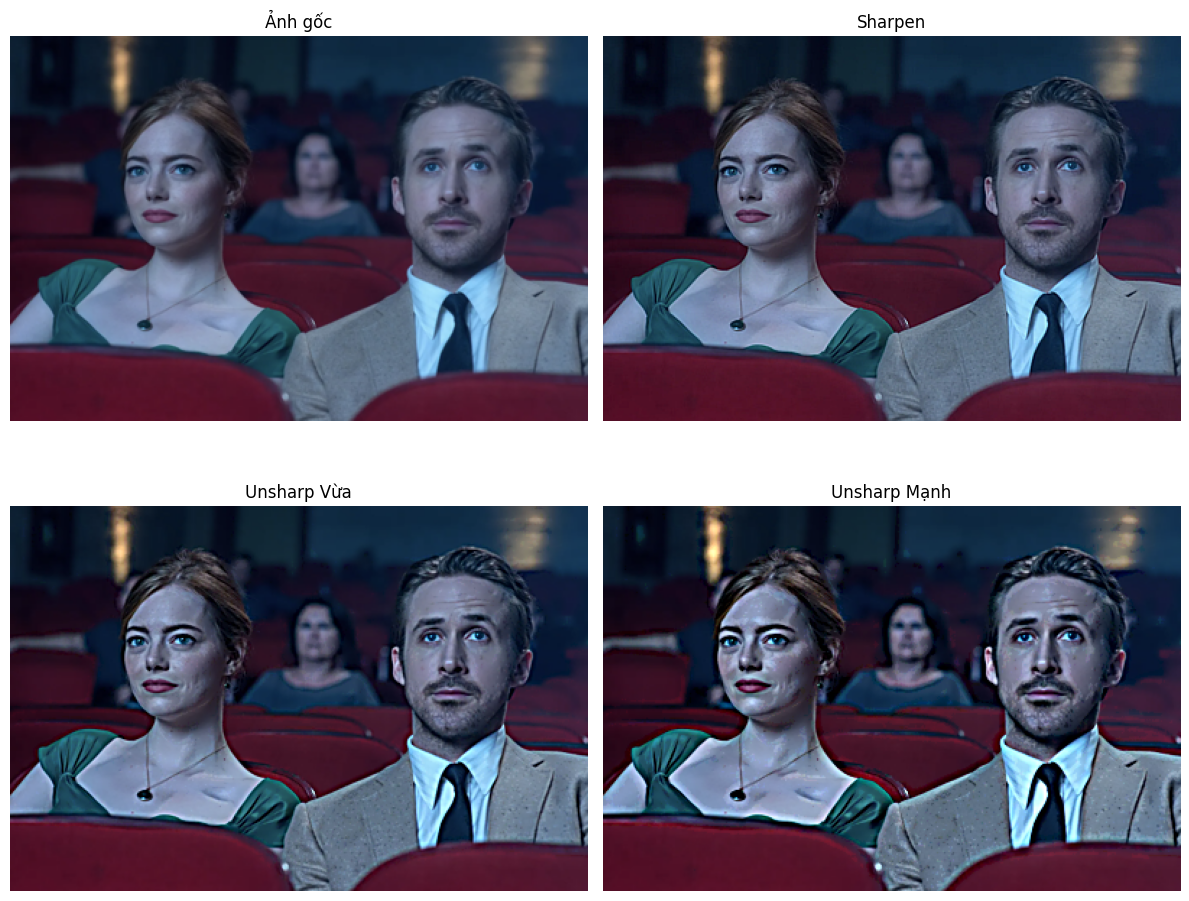

In [7]:
# Các loại sharpen
def thuc_hanh_sharpen():
  # Sharpen cơ bản
  sharpen_img = img_goc.filter(ImageFilter.SHARPEN)
  # Unsharp mask với các tham số khác nhau
  unsharp_nhe = img_goc.filter(ImageFilter.UnsharpMask(radius=1, percent=100, threshold=1))
  unsharp_vua = img_goc.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3))
  unsharp_manh = img_goc.filter(ImageFilter.UnsharpMask(radius=3, percent=200,
  threshold=5))
  # Hiển thị kết quả
  fig, axes = plt.subplots(2, 2, figsize=(12, 10))
  images = [img_goc, sharpen_img, unsharp_vua, unsharp_manh]
  titles = ['Ảnh gốc', 'Sharpen', 'Unsharp Vừa', 'Unsharp Mạnh']
  for i, (image, title) in enumerate(zip(images, titles)):
    row, col = i // 2, i % 2
    axes[row, col].imshow(image)
    axes[row, col].set_title(title)
    axes[row, col].axis('off')
  plt.tight_layout()
  plt.show()
  return sharpen_img, unsharp_vua
sharpen_img, unsharp_img = thuc_hanh_sharpen()

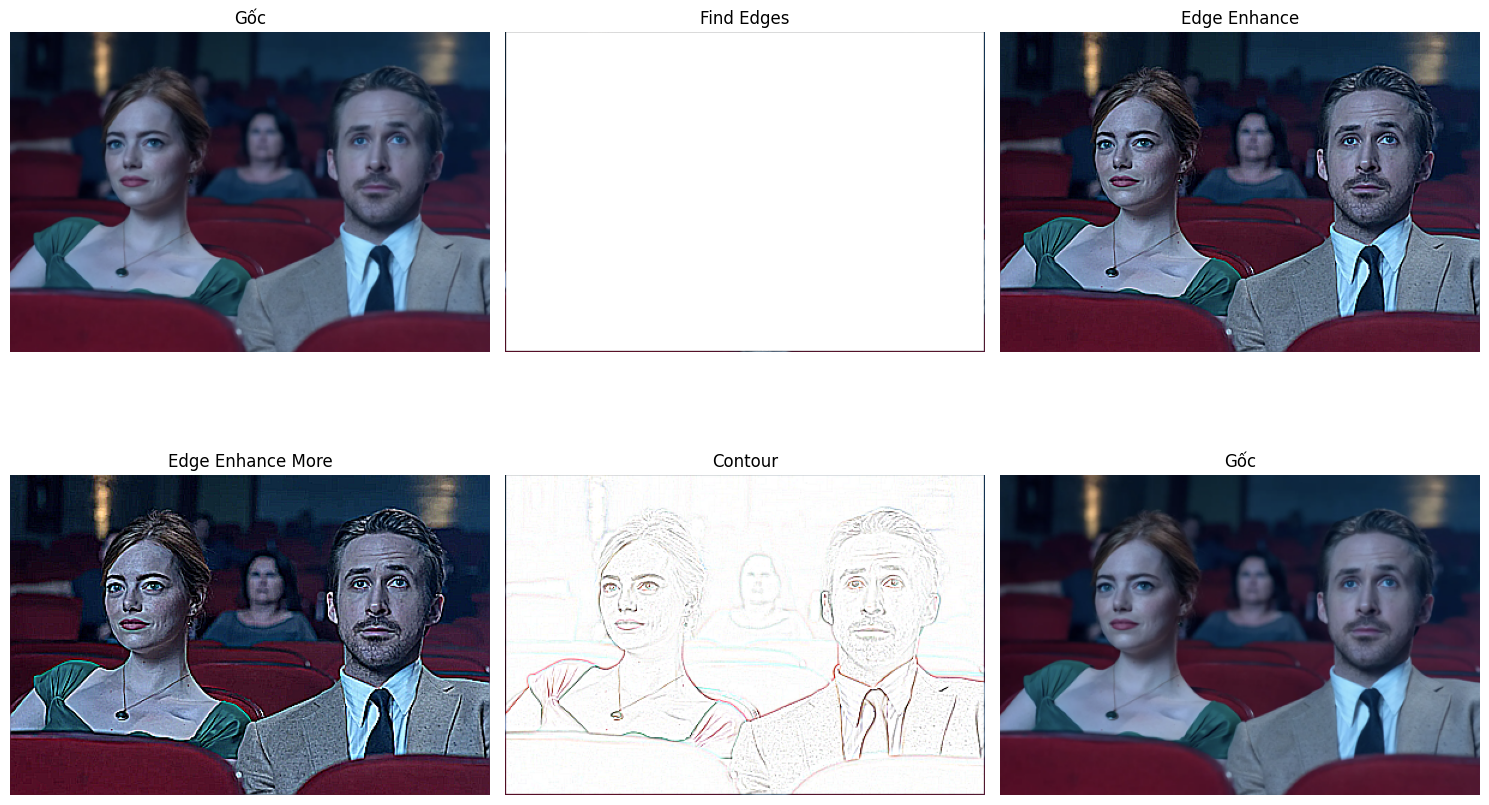

In [8]:
def thuc_hanh_edge_detection():
  # Các bộ lọc edge
  find_edges = img_goc.filter(ImageFilter.FIND_EDGES)
  edge_enhance = img_goc.filter(ImageFilter.EDGE_ENHANCE)
  edge_enhance_more = img_goc.filter(ImageFilter.EDGE_ENHANCE_MORE)
  contour = img_goc.filter(ImageFilter.CONTOUR)
  # Hiển thị kết quả
  fig, axes = plt.subplots(2, 3, figsize=(15, 10))
  images = [img_goc, find_edges, edge_enhance, edge_enhance_more, contour, img_goc]
  titles = ['Gốc', 'Find Edges', 'Edge Enhance', 'Edge Enhance More', 'Contour', 'Gốc']
  for i, (image, title) in enumerate(zip(images, titles)):
    row, col = i // 3, i % 3
    axes[row, col].imshow(image)
    axes[row, col].set_title(title)
    axes[row, col].axis('off')
  plt.tight_layout()
  plt.show()
  return find_edges, edge_enhance, contour
find_edges, edge_enhance, contour = thuc_hanh_edge_detection()

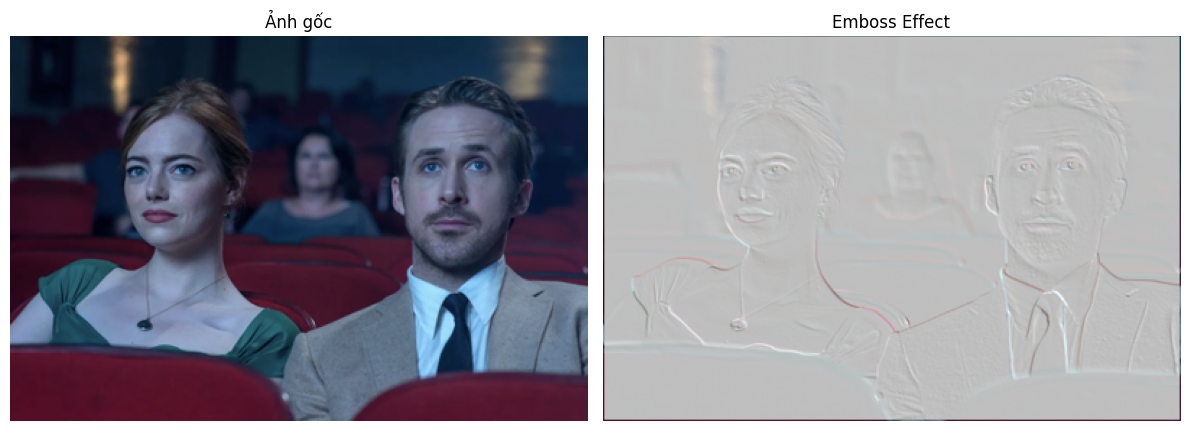

In [9]:
def thuc_hanh_emboss():
  emboss_img = img_goc.filter(ImageFilter.EMBOSS)
  # So sánh
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  axes[0].imshow(img_goc)
  axes[0].set_title('Ảnh gốc')
  axes[0].axis('off')
  axes[1].imshow(emboss_img)
  axes[1].set_title('Emboss Effect')
  axes[1].axis('off')
  plt.tight_layout()
  plt.show()
  return emboss_img
emboss_img = thuc_hanh_emboss()

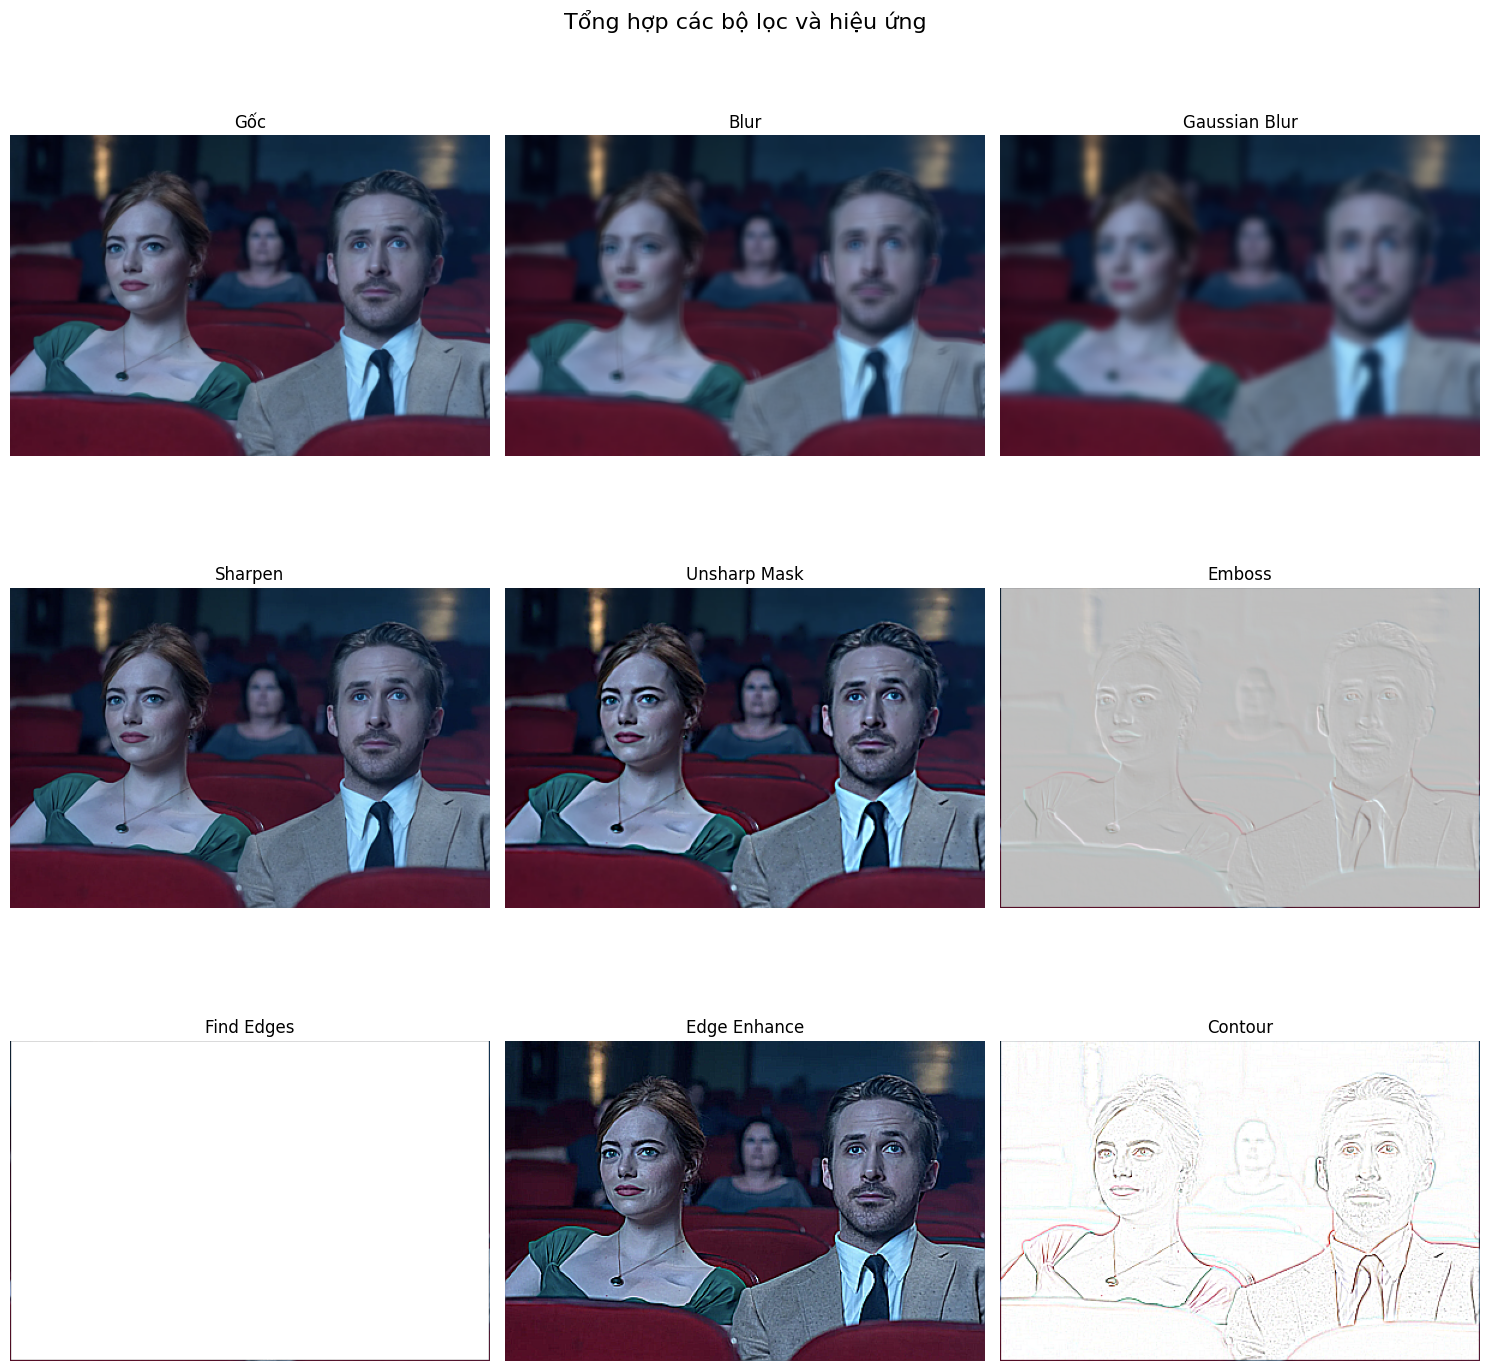

In [10]:
def tong_hop_hieu_ung():
  # Tạo tất cả hiệu ứng
  effects = {
  'Gốc': img_goc,
  'Blur': img_goc.filter(ImageFilter.BLUR),
  'Gaussian Blur': img_goc.filter(ImageFilter.GaussianBlur(radius=3)),
  'Sharpen': img_goc.filter(ImageFilter.SHARPEN),
  'Unsharp Mask': img_goc.filter(ImageFilter.UnsharpMask(radius=2, percent=150,
  threshold=3)),
  'Emboss': img_goc.filter(ImageFilter.EMBOSS),
  'Find Edges': img_goc.filter(ImageFilter.FIND_EDGES),
  'Edge Enhance': img_goc.filter(ImageFilter.EDGE_ENHANCE),
  'Contour': img_goc.filter(ImageFilter.CONTOUR)
  }
  # Hiển thị grid 3x3
  fig, axes = plt.subplots(3, 3, figsize=(15, 15))
  fig.suptitle('Tổng hợp các bộ lọc và hiệu ứng', fontsize=16)
  for i, (name, image) in enumerate(effects.items()):
    row, col = i // 3, i % 3
    axes[row, col].imshow(image)
    axes[row, col].set_title(name)
    axes[row, col].axis('off')
  plt.tight_layout()
  plt.show()
  return effects
all_effects = tong_hop_hieu_ung()

In [12]:
# Lưu các ảnh đã xử lý
def luu_ket_qua():
  # Tạo thư mục kết quả
  thu_muc_ket_qua = "/content/drive/MyDrive/Lab_Results/"
  if not os.path.exists(thu_muc_ket_qua):
   os.makedirs(thu_muc_ket_qua)
  # Lưu các hiệu ứng
  effects_to_save = {
  'blur': img_goc.filter(ImageFilter.BLUR),
  'gaussian_blur': img_goc.filter(ImageFilter.GaussianBlur(radius=3)),
  'sharpen': img_goc.filter(ImageFilter.SHARPEN),
  'unsharp': img_goc.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3)),
  'emboss': img_goc.filter(ImageFilter.EMBOSS),
  'edges': img_goc.filter(ImageFilter.FIND_EDGES),
  'contour': img_goc.filter(ImageFilter.CONTOUR)
  }
  ten_anh_goc = os.path.splitext(danh_sach_anh[0])[0]
  for effect_name, image in effects_to_save.items():
    filename = f"{ten_anh_goc}_{effect_name}.png"
    filepath = os.path.join(thu_muc_ket_qua, filename)
    image.save(filepath, quality=95)
    print(f"✓ Đã lưu: {filename}")
    print(f"\nTất cả ảnh đã lưu tại: {thu_muc_ket_qua}")
luu_ket_qua()

✓ Đã lưu: bai3_flip_horizontal_blur.png

Tất cả ảnh đã lưu tại: /content/drive/MyDrive/Lab_Results/
✓ Đã lưu: bai3_flip_horizontal_gaussian_blur.png

Tất cả ảnh đã lưu tại: /content/drive/MyDrive/Lab_Results/
✓ Đã lưu: bai3_flip_horizontal_sharpen.png

Tất cả ảnh đã lưu tại: /content/drive/MyDrive/Lab_Results/
✓ Đã lưu: bai3_flip_horizontal_unsharp.png

Tất cả ảnh đã lưu tại: /content/drive/MyDrive/Lab_Results/
✓ Đã lưu: bai3_flip_horizontal_emboss.png

Tất cả ảnh đã lưu tại: /content/drive/MyDrive/Lab_Results/
✓ Đã lưu: bai3_flip_horizontal_edges.png

Tất cả ảnh đã lưu tại: /content/drive/MyDrive/Lab_Results/
✓ Đã lưu: bai3_flip_horizontal_contour.png

Tất cả ảnh đã lưu tại: /content/drive/MyDrive/Lab_Results/


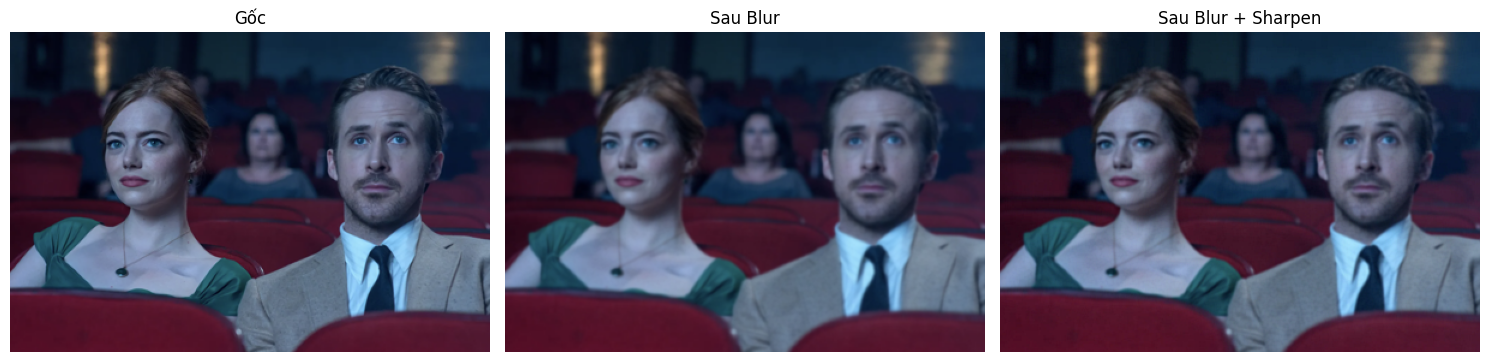

In [13]:
def hieu_ung_ket_hop():
  # Bước 1: Áp dụng blur nhẹ
  step1 = img_goc.filter(ImageFilter.GaussianBlur(radius=1))
  # Bước 2: Áp dụng sharpen
  step2 = step1.filter(ImageFilter.SHARPEN)
  # Hiển thị kết quả
  fig, axes = plt.subplots(1, 3, figsize=(15, 5))
  images = [img_goc, step1, step2]
  titles = ['Gốc', 'Sau Blur', 'Sau Blur + Sharpen']
  for i, (image, title) in enumerate(zip(images, titles)):
    axes[i].imshow(image)
    axes[i].set_title(title)
    axes[i].axis('off')
  plt.tight_layout()
  plt.show()
  return step2
# Chạy thử nghiệm
result = hieu_ung_ket_hop()